# AI-Enabled Digital Twin for Fouling-Aware Optimization of Textile Wastewater Reuse
## Stage 1: Mechanistic Reverse Osmosis Baseline Model Validation

### 1. Research Background & Objectives
This notebook verifies and validates the physics-based mechanistic reverse osmosis (RO) model based on the published research by:
> **Sowgath, Sarker & Mujtaba (2025)**  
> *"Design of Multi Stage Reverse Osmosis Process for Reuse of Textile Wastewater"*, Chemical Engineering Transactions, Vol. 117.

The operational reference data originates from an industrial MBR–RO wastewater treatment plant at Nice Cotton Limited (Gazipur, Bangladesh).

**Objective of Stage 1:**
- Formulate and solve the coupled solution-diffusion and film-theory transport equations for the baseline **Toray TML20D-400** spiral-wound RO membrane element.
- Strictly separate **source-reported values** from **modeling assumptions**.
- Rigorously verify fluid and solute mass conservation.
- Analyze physical membrane performance (flux, recovery, rejection, concentration polarization, osmotic pressures, and pump specific energy consumption).
- Prepare the modular codebase for Stage 2 (multi-element two-stage industrial plant simulation).

In [1]:
import os
import sys
from pathlib import Path
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add src/ to python path
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root / "src"))

from ro_model import (
    simulate_ro,
    MembraneElementProperties,
    SimulationConfig,
    validate_physical_bounds
)

print("ro_model package successfully loaded!")

ro_model package successfully loaded!


### 2. Load Configuration & Baseline Parameters

In [2]:
config_path = project_root / "config" / "baseline.yaml"
with open(config_path, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

print("--- Source-Reported Parameters ---")
for k, v in config["source_reported"].items():
    print(f"  {k:<30}: {v}")

print("\n--- Modeling Assumptions ---")
for k, v in config["assumptions"].items():
    print(f"  {k:<30}: {v}")

--- Source-Reported Parameters ---
  membrane_area                 : 37.0
  membrane_diameter             : 0.201
  Aw                            : 9.08e-05
  As                            : 1.1834e-09
  feed_flow                     : 30.0
  feed_concentration            : 2000.0
  feed_pressure_psi             : 225.0
  feed_pressure_bar             : 15.5132
  temperature_celsius           : 25.0
  max_operating_pressure_bar    : 41.0
  module_feed_flow_min_m3_day   : 31.8
  module_feed_flow_max_m3_day   : 39.7
  nominal_water_recovery        : 0.15
  nominal_salt_rejection_min    : 0.9965
  nominal_salt_rejection_max    : 0.998

--- Modeling Assumptions ---
  pump_efficiency               : 0.8
  permeate_pressure_bar         : 1.01325
  inlet_feed_pressure_bar       : 1.01325
  vanthoff_factor               : 2.0
  solute_molar_mass_g_mol       : 58.44
  cp_mode                       : mode_a
  mass_transfer_coefficient     : 5e-05
  feed_spacer_thickness_mm      : 0.76
  feed_cha

### 3. Run Mechanistic Simulation (Baseline Operating Point)

In [3]:
mem_props = MembraneElementProperties.from_config_dict(config)
sim_cfg = SimulationConfig.from_config_dict(config)
src = config["source_reported"]

res = simulate_ro(
    feed_flow=src["feed_flow"],
    feed_tds=src["feed_concentration"],
    pressure=src["feed_pressure_bar"],
    temperature=src["temperature_celsius"],
    pressure_unit="bar",
    membrane_properties=mem_props,
    config=sim_cfg
)

print(res.format_summary_table())

               REVERSE OSMOSIS SIMULATION RESULTS SUMMARY
1. OPERATING STREAM CONDITIONS:
   Feed Flow (Qf)               :    30.0000 m3/h  (  8.3333 L/s)
   Feed Pressure (Pf)           :    15.5132 bar    (  225.00 psi)
   Feed Salinity (Cf)           :    2000.00 mg/L  (  2.0000 g/L)
   Temperature (T)              :      25.00 degC   (  298.15 K)
------------------------------------------------------------------------------
2. OUTLET STREAM FLOWS & SALINITIES:
   Permeate Flow (Qp)           :    11.9223 m3/h
   Concentrate Flow (Qr)        :    18.0777 m3/h
   Permeate TDS (Cp)            :       0.21 mg/L
   Concentrate TDS (Cr)         :    3318.87 mg/L
   Membrane Surface TDS (Cm)    :   15929.68 mg/L
------------------------------------------------------------------------------
3. MEMBRANE FLUX & SEPARATION PERFORMANCE:
   Water Volumetric Flux (Jw)   :   322.2246 LMH    (8.9507e-05 m/s)
   Salt Mass Flux (Js)          :     0.0679 g/(m2-h) (1.8851e-08 kg/(m2-s))
   Water Rec

### 4. Mass and Solute Conservation Verification

In [4]:
checks = validate_physical_bounds(res)
print("Automated Scientific Boundary & Mass Balance Checks:")
for k, v in checks.items():
    status = "PASS [OK]" if v else "FAIL [X]"
    print(f"  - {k:<38}: {status}")

print(f"\nWater Mass Balance Error : {res.water_mass_balance_error_m3_s:.4e} m3/s ({res.water_mass_balance_error_percent:.6f}%)")
print(f"Solute Mass Balance Error: {res.solute_mass_balance_error_kg_s:.4e} kg/s ({res.solute_mass_balance_error_percent:.6f}%)")

Automated Scientific Boundary & Mass Balance Checks:
  - permeate_flow_less_than_feed          : PASS [OK]
  - concentrate_flow_nonnegative          : PASS [OK]
  - permeate_tds_less_than_feed           : PASS [OK]
  - recovery_in_valid_range               : PASS [OK]
  - rejection_in_valid_range              : PASS [OK]
  - pressure_within_limits                : PASS [OK]
  - effective_driving_force_positive      : PASS [OK]
  - water_mass_balance_passed             : PASS [OK]
  - solute_mass_balance_passed            : PASS [OK]

Water Mass Balance Error : 0.0000e+00 m3/s (0.000000%)
Solute Mass Balance Error: 0.0000e+00 kg/s (0.000000%)


### 5. Summary Performance Metrics Table

In [5]:
metrics_data = {
    "Metric": [
        "Feed Flow Rate (Qf)",
        "Feed TDS (Cf)",
        "Feed Pressure (Pf)",
        "Permeate Flow (Qp)",
        "Concentrate Flow (Qr)",
        "Permeate TDS (Cp)",
        "Concentrate TDS (Cr)",
        "Water Volumetric Flux (Jw)",
        "Water Recovery (WR)",
        "Salt Rejection (SR)",
        "Concentration Polarization Modulus (Cm/Cb)",
        "Feed Osmotic Pressure (pi_f)",
        "Effective Transmembrane Driving Pressure (dP_eff)",
        "Pump Electrical Power",
        "Specific Energy Consumption (SEC)"
    ],
    "Value": [
        f"{res.feed_flow_m3_hr:.2f}",
        f"{res.feed_tds_mg_l:.1f}",
        f"{res.feed_pressure_bar:.2f}",
        f"{res.permeate_flow_m3_hr:.4f}",
        f"{res.concentrate_flow_m3_hr:.4f}",
        f"{res.permeate_tds_mg_l:.2f}",
        f"{res.concentrate_tds_mg_l:.2f}",
        f"{res.water_flux_lmh:.2f}",
        f"{res.water_recovery_percent:.2f}",
        f"{res.salt_rejection_percent:.4f}",
        f"{res.polarization_modulus:.4f}",
        f"{res.feed_osmotic_pressure_bar:.3f}",
        f"{res.effective_driving_pressure_bar:.3f}",
        f"{res.pump_electrical_power_kw:.2f}",
        f"{res.sec_kwh_per_m3:.2f}"
    ],
    "Unit": [
        "m3/h", "mg/L", "bar", "m3/h", "m3/h", "mg/L", "mg/L", "LMH", "%", "%", "-", "bar", "bar", "kW", "kWh/m3"
    ]
}
df_metrics = pd.DataFrame(metrics_data)
display(df_metrics)

,Metric,Value,Unit
0,Feed Flow Rate (Qf),30.00,m3/h
1,Feed TDS (Cf),2000.0,mg/L
2,Feed Pressure (Pf),15.51,bar
3,Permeate Flow (Qp),11.9223,m3/h
4,Concentrate Flow (Qr),18.0777,m3/h
5,Permeate TDS (Cp),0.21,mg/L
6,Concentrate TDS (Cr),3318.87,mg/L
7,Water Volumetric Flux (Jw),322.22,LMH
8,Water Recovery (WR),39.74,%
9,Salt Rejection (SR),99.9895,%


### 6. Pressure Sensitivity Analysis (10 to 35 bar)

In [6]:
pressures = np.linspace(10.0, 35.0, 26)
sweep_results = []

for p in pressures:
    r = simulate_ro(
        feed_flow=src["feed_flow"],
        feed_tds=src["feed_concentration"],
        pressure=p,
        temperature=src["temperature_celsius"],
        membrane_properties=mem_props,
        config=sim_cfg
    )
    sweep_results.append(r.to_dict())

df_sweep = pd.DataFrame(sweep_results)
print(f"Computed sensitivity sweep across {len(df_sweep)} pressure operating points.")

Computed sensitivity sweep across 26 pressure operating points.


### 7. Visualization & Scientific Diagnostics

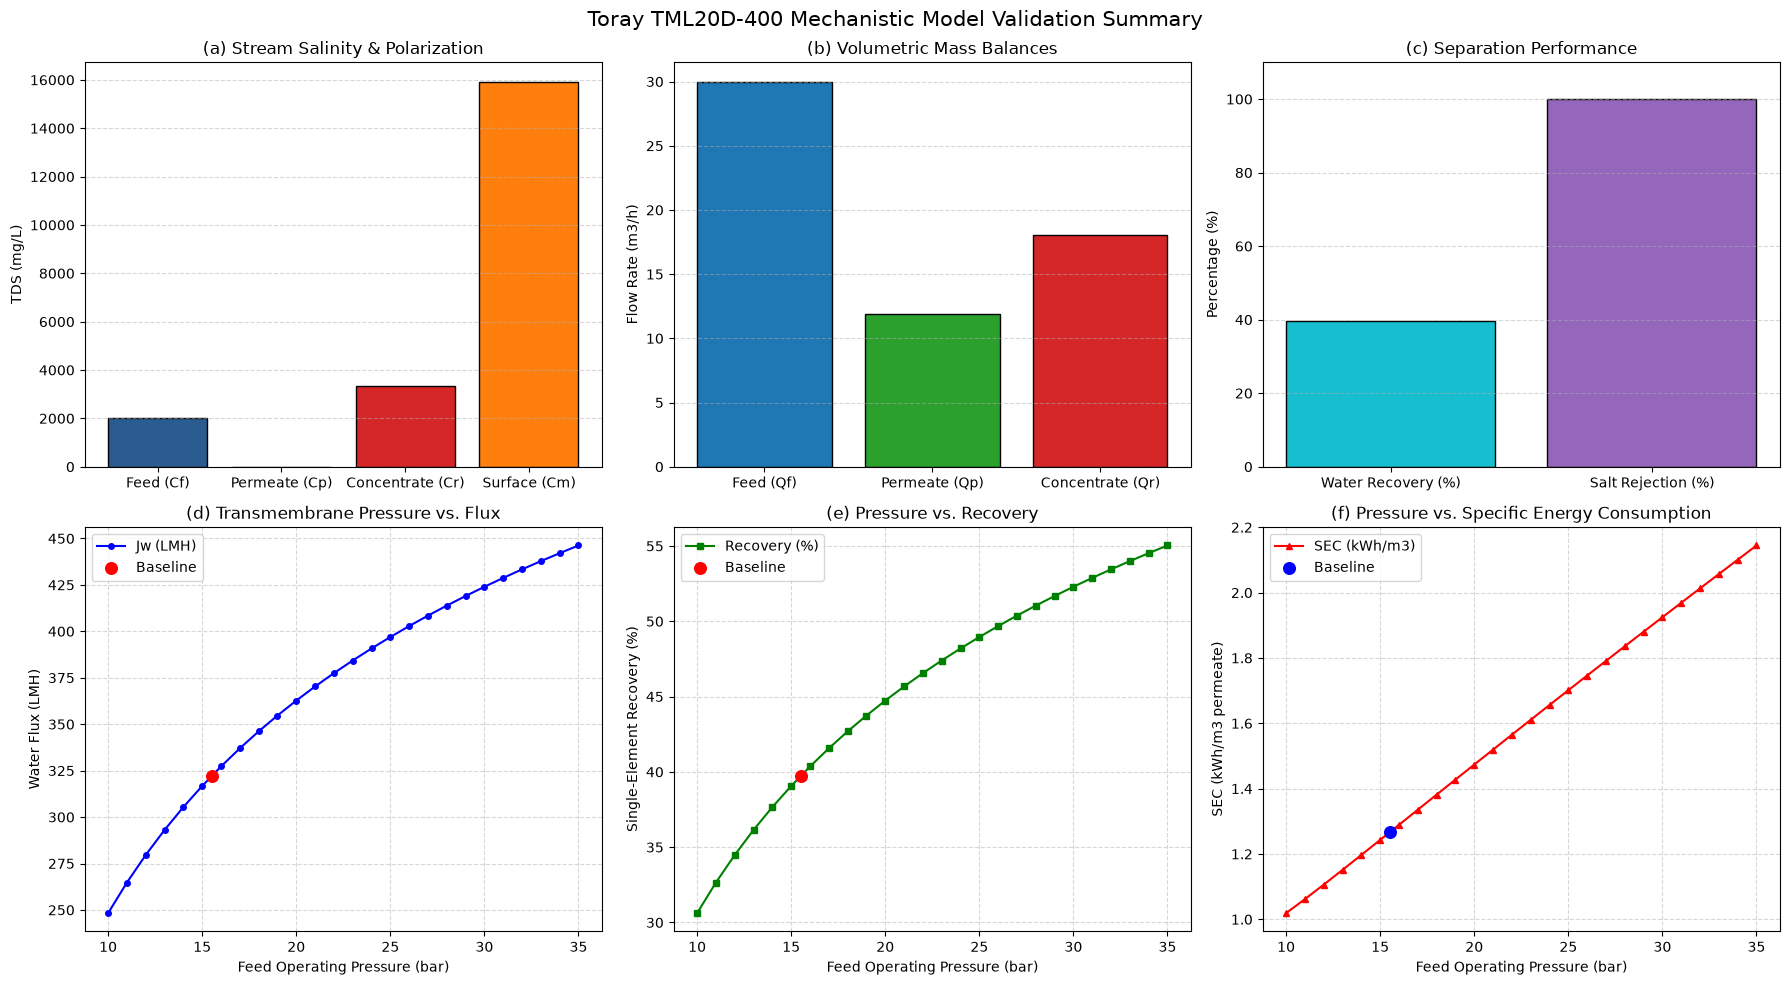

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Panel 1: TDS
streams = ["Feed (Cf)", "Permeate (Cp)", "Concentrate (Cr)", "Surface (Cm)"]
tds_vals = [res.feed_tds_mg_l, res.permeate_tds_mg_l, res.concentrate_tds_mg_l, res.membrane_surface_tds_mg_l]
axes[0, 0].bar(streams, tds_vals, color=["#2b5c8f", "#2ca02c", "#d62728", "#ff7f0e"], edgecolor="black")
axes[0, 0].set_ylabel("TDS (mg/L)")
axes[0, 0].set_title("(a) Stream Salinity & Polarization")
axes[0, 0].grid(axis="y", linestyle="--", alpha=0.5)

# Panel 2: Flows
flow_names = ["Feed (Qf)", "Permeate (Qp)", "Concentrate (Qr)"]
flow_vals = [res.feed_flow_m3_hr, res.permeate_flow_m3_hr, res.concentrate_flow_m3_hr]
axes[0, 1].bar(flow_names, flow_vals, color=["#1f77b4", "#2ca02c", "#d62728"], edgecolor="black")
axes[0, 1].set_ylabel("Flow Rate (m3/h)")
axes[0, 1].set_title("(b) Volumetric Mass Balances")
axes[0, 1].grid(axis="y", linestyle="--", alpha=0.5)

# Panel 3: Recovery & Rejection
axes[0, 2].bar(["Water Recovery (%)", "Salt Rejection (%)"], [res.water_recovery_percent, res.salt_rejection_percent],
               color=["#17becf", "#9467bd"], edgecolor="black")
axes[0, 2].set_ylabel("Percentage (%)")
axes[0, 2].set_title("(c) Separation Performance")
axes[0, 2].set_ylim(0, 110)
axes[0, 2].grid(axis="y", linestyle="--", alpha=0.5)

# Panel 4: Pressure vs Flux
axes[1, 0].plot(df_sweep["feed_pressure_bar"], df_sweep["water_flux_lmh"], "b-o", markersize=4, label="Jw (LMH)")
axes[1, 0].scatter([res.feed_pressure_bar], [res.water_flux_lmh], color="red", s=70, zorder=5, label="Baseline")
axes[1, 0].set_xlabel("Feed Operating Pressure (bar)")
axes[1, 0].set_ylabel("Water Flux (LMH)")
axes[1, 0].set_title("(d) Transmembrane Pressure vs. Flux")
axes[1, 0].grid(True, linestyle="--", alpha=0.5)
axes[1, 0].legend()

# Panel 5: Pressure vs Recovery
axes[1, 1].plot(df_sweep["feed_pressure_bar"], df_sweep["water_recovery_percent"], "g-s", markersize=4, label="Recovery (%)")
axes[1, 1].scatter([res.feed_pressure_bar], [res.water_recovery_percent], color="red", s=70, zorder=5, label="Baseline")
axes[1, 1].set_xlabel("Feed Operating Pressure (bar)")
axes[1, 1].set_ylabel("Single-Element Recovery (%)")
axes[1, 1].set_title("(e) Pressure vs. Recovery")
axes[1, 1].grid(True, linestyle="--", alpha=0.5)
axes[1, 1].legend()

# Panel 6: Pressure vs SEC
axes[1, 2].plot(df_sweep["feed_pressure_bar"], df_sweep["sec_kwh_per_m3"], "r-^", markersize=4, label="SEC (kWh/m3)")
axes[1, 2].scatter([res.feed_pressure_bar], [res.sec_kwh_per_m3], color="blue", s=70, zorder=5, label="Baseline")
axes[1, 2].set_xlabel("Feed Operating Pressure (bar)")
axes[1, 2].set_ylabel("SEC (kWh/m3 permeate)")
axes[1, 2].set_title("(f) Pressure vs. Specific Energy Consumption")
axes[1, 2].grid(True, linestyle="--", alpha=0.5)
axes[1, 2].legend()

plt.suptitle("Toray TML20D-400 Mechanistic Model Validation Summary", fontsize=15)
plt.tight_layout()
plt.show()